**Grupo 2**

---

Edwin Pérez Santana 2024-0517

Idelsa Maria lugo Nivar 2024-0518

Angel Abreu 2024-0524

Luis González 2024-0509

---

**Dataset utilizado: Mall Customers Dataset**

Número de registros: 200 clientes

Número de características: 5 variables (incluyendo el ID)

Fuente: Kaggle - https://www.kaggle.com/datasets/amisha0528/mall-customers-dataset

In [ ]:
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Importación y EDA del Dataset

In [ ]:
# Download latest version
path = kagglehub.dataset_download("amisha0528/mall-customers-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mall-customers-dataset' dataset.
Path to dataset files: /kaggle/input/mall-customers-dataset


In [ ]:
df = pd.read_csv("/root/.cache/kagglehub/datasets/amisha0528/mall-customers-dataset/versions/1/Mall_Customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
# Configurar estilo de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Exploración inicial
print(f"\nInformación del dataset:")
print(df.info())
print(f"\nEstadísticas descriptivas:")
print(df.describe())


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Estadísticas descriptivas:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000    

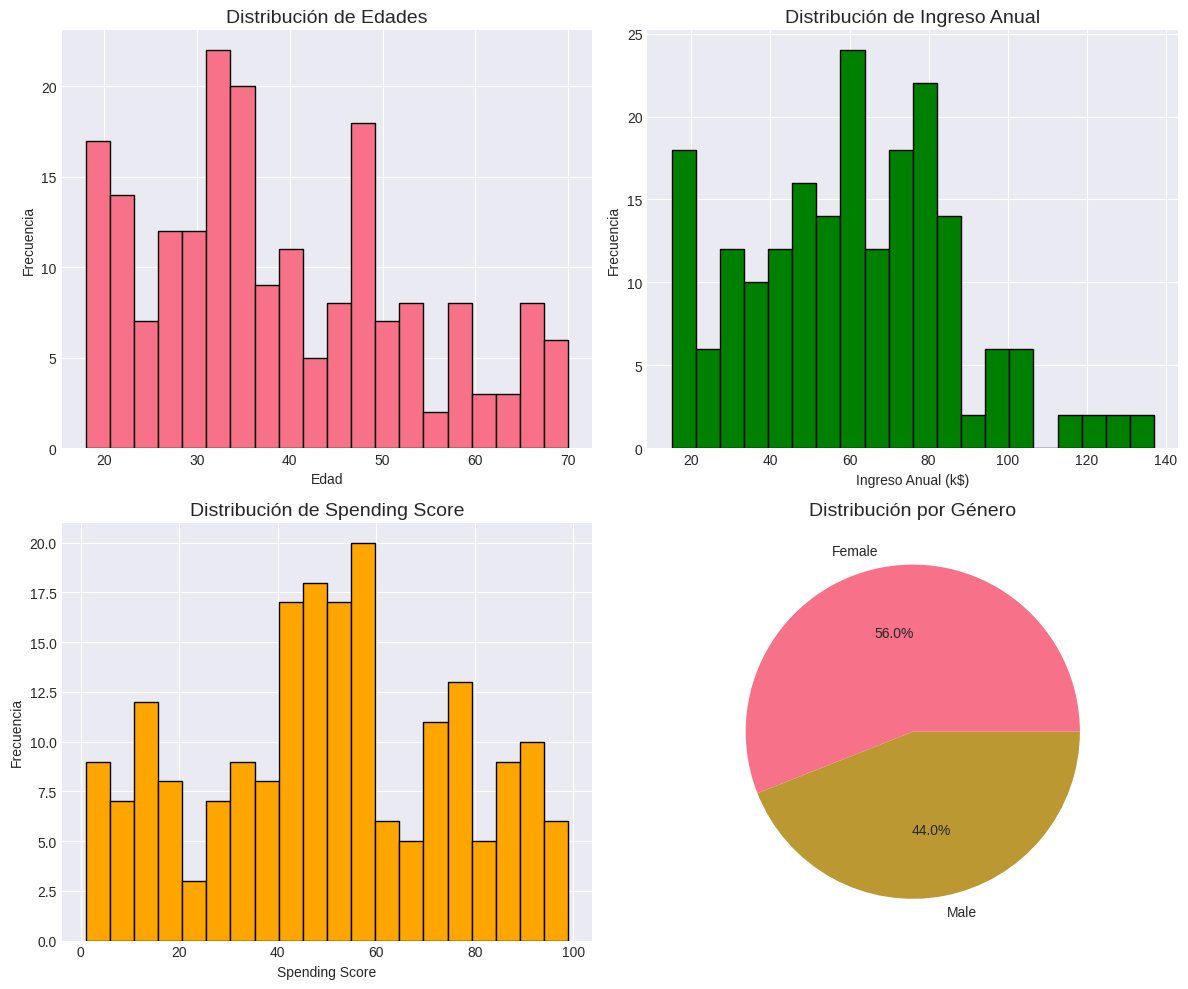

In [ ]:
# Visualizar distribución de características
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distribución de Edad
axes[0, 0].hist(df['Age'], bins=20, edgecolor='black')
axes[0, 0].set_title('Distribución de Edades', fontsize=14)
axes[0, 0].set_xlabel('Edad')
axes[0, 0].set_ylabel('Frecuencia')

# Distribución de Ingreso Anual
axes[0, 1].hist(df['Annual Income (k$)'], bins=20, edgecolor='black', color='green')
axes[0, 1].set_title('Distribución de Ingreso Anual', fontsize=14)
axes[0, 1].set_xlabel('Ingreso Anual (k$)')
axes[0, 1].set_ylabel('Frecuencia')

# Distribución de Spending Score
axes[1, 0].hist(df['Spending Score (1-100)'], bins=20, edgecolor='black', color='orange')
axes[1, 0].set_title('Distribución de Spending Score', fontsize=14)
axes[1, 0].set_xlabel('Spending Score')
axes[1, 0].set_ylabel('Frecuencia')

# Distribución por Género
gender_counts = df['Genre'].value_counts()
axes[1, 1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
axes[1, 1].set_title('Distribución por Género', fontsize=14)

plt.tight_layout()
plt.show()

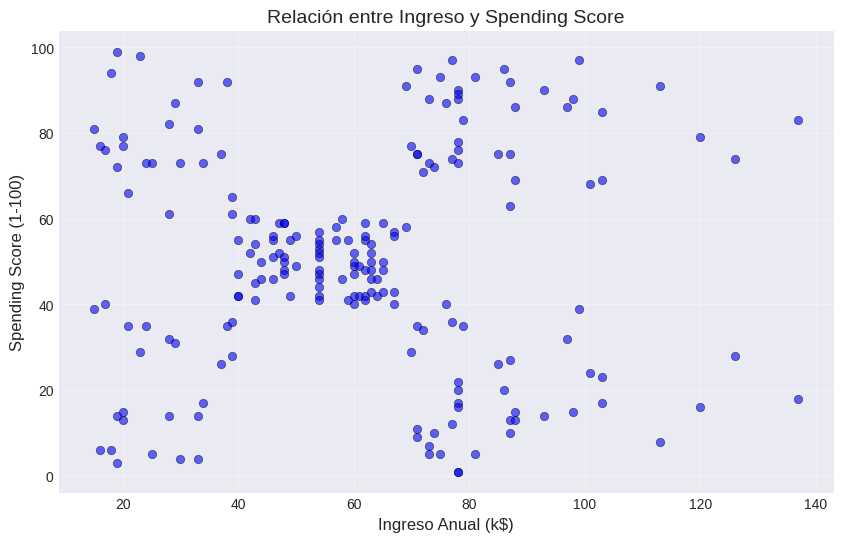

In [ ]:
# Visualizar relación entre Ingreso y Spending Score
plt.figure(figsize=(10, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            alpha=0.6, c='blue', edgecolors='black', linewidth=0.5)
plt.xlabel('Ingreso Anual (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Relación entre Ingreso y Spending Score', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# K-Means

In [ ]:
# 1. SELECCIONAR CARACTERÍSTICAS
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# 2. ESCALAR DATOS
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. MÉTODO DEL CODO - ENCONTRAR K ÓPTIMO
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

In [ ]:
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

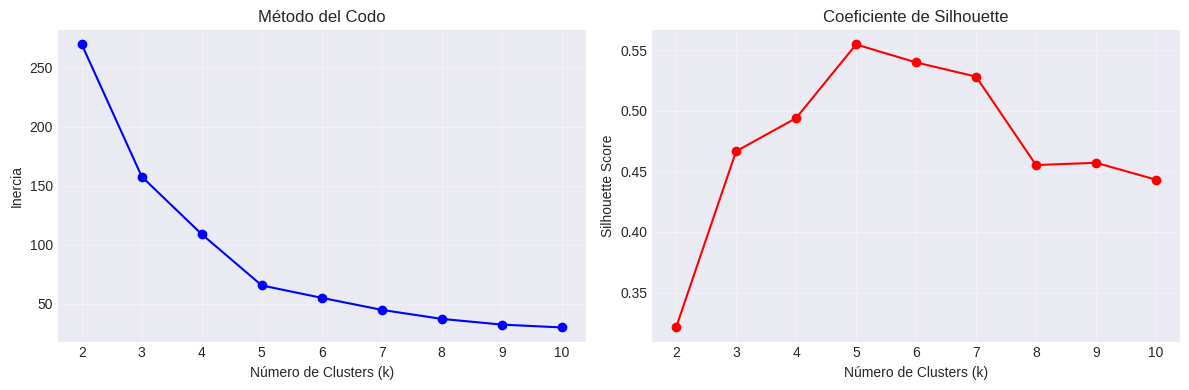

In [ ]:
# Visualizar método del codo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo')
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Coeficiente de Silhouette')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Se seleccionó k = 5 porque en el método del codo se observa el punto donde la reducción de inercia deja de ser significativa, y además coincide con el valor máximo del coeficiente de silhouette, indicando clusters bien definidos y separados.”

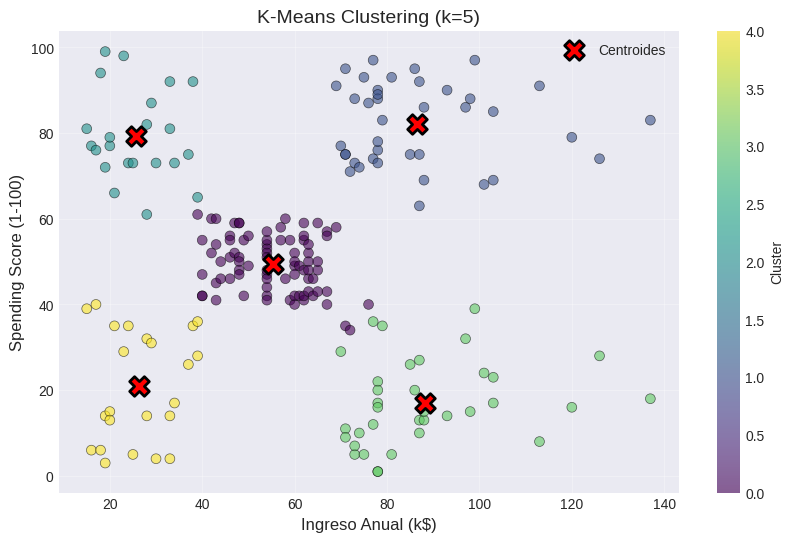

In [ ]:
# 4. APLICAR K-MEANS CON K ÓPTIMO (k=5 basado en las gráficas)
k_optimo = 5
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 5. VISUALIZAR RESULTADOS
plt.figure(figsize=(10, 6))

# Desescalar centroides para visualización
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Graficar clusters
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis',
                      s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X',
            s=200, linewidth=2, edgecolors='black', label='Centroides')
plt.xlabel('Ingreso Anual (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title(f'K-Means Clustering (k={k_optimo})', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

El modelo segmentó correctamente en 5 perfiles claros de clientes, lo que permite:

Identificar clientes valiosos (alto ingreso + alto gasto)
Detectar oportunidades (alto ingreso + bajo gasto)
Optimizar estrategias de marketing según cada grupo

“El algoritmo K-Means permitió identificar cinco segmentos de clientes bien definidos según su ingreso y comportamiento de gasto, facilitando la toma de decisiones estratégicas para marketing y fidelización.”

In [ ]:
# 6. ESTADÍSTICAS DE LOS CLUSTERS
print("\n" + "="*50)
print(f"ESTADÍSTICAS POR CLUSTER (k={k_optimo})")
print("="*50)

df['Cluster'] = clusters

for i in range(k_optimo):
    cluster_data = df[df['Cluster'] == i]
    print(f"\nCLUSTER {i} ({len(cluster_data)} clientes):")
    print(f"   Ingreso promedio: ${cluster_data['Annual Income (k$)'].mean():.2f}k")
    print(f"   Spending Score promedio: {cluster_data['Spending Score (1-100)'].mean():.2f}")
    print(f"   Edad promedio: {cluster_data['Age'].mean():.1f} años")
    print(f"   Género: {cluster_data['Genre'].value_counts().index[0]} ({cluster_data['Genre'].value_counts().values[0]})")

# 8. PERFILES DE CLIENTES
print("\n" + "="*50)
print("PERFILES DE CLIENTES POR CLUSTER (CORREGIDO)")
print("="*50)

for i in range(k_optimo):
    cluster_data = df[df['Cluster'] == i]

    ingreso = cluster_data['Annual Income (k$)'].mean()
    gasto = cluster_data['Spending Score (1-100)'].mean()

    # Clasificación simple
    if ingreso > 70 and gasto > 60:
        perfil = "INGRESO ALTO - GASTO ALTO: Clientes premium"
        estrategia = "Programa de lealtad y productos exclusivos"

    elif ingreso > 70 and gasto < 40:
        perfil = "INGRESO ALTO - GASTO BAJO: Clientes con potencial"
        estrategia = "Incentivar compras (marketing personalizado)"

    elif ingreso < 40 and gasto > 60:
        perfil = "INGRESO BAJO - GASTO ALTO: Compradores impulsivos"
        estrategia = "Promociones y descuentos"

    elif ingreso < 40 and gasto < 40:
        perfil = "INGRESO BAJO - GASTO BAJO: Clientes económicos"
        estrategia = "Productos básicos y bajo enfoque"

    else:
        perfil = "INGRESO MEDIO - GASTO MEDIO: Clientes promedio"
        estrategia = "Fidelización"

    print(f"\nCluster {i}: {perfil}")
    print(f"   • Estrategia: {estrategia}")


ESTADÍSTICAS POR CLUSTER (k=5)

CLUSTER 0 (81 clientes):
   Ingreso promedio: $55.30k
   Spending Score promedio: 49.52
   Edad promedio: 42.7 años
   Género: Female (48)

CLUSTER 1 (39 clientes):
   Ingreso promedio: $86.54k
   Spending Score promedio: 82.13
   Edad promedio: 32.7 años
   Género: Female (21)

CLUSTER 2 (22 clientes):
   Ingreso promedio: $25.73k
   Spending Score promedio: 79.36
   Edad promedio: 25.3 años
   Género: Female (13)

CLUSTER 3 (35 clientes):
   Ingreso promedio: $88.20k
   Spending Score promedio: 17.11
   Edad promedio: 41.1 años
   Género: Male (19)

CLUSTER 4 (23 clientes):
   Ingreso promedio: $26.30k
   Spending Score promedio: 20.91
   Edad promedio: 45.2 años
   Género: Female (14)

PERFILES DE CLIENTES POR CLUSTER (CORREGIDO)

Cluster 0: INGRESO MEDIO - GASTO MEDIO: Clientes promedio
   • Estrategia: Fidelización

Cluster 1: INGRESO ALTO - GASTO ALTO: Clientes premium
   • Estrategia: Programa de lealtad y productos exclusivos

Cluster 2: INGRESO

**Conclusiones de K-Means: **

El modelo de K-Means con k = 5 permitió identificar cinco segmentos de clientes bien diferenciados según su nivel de ingresos y comportamiento de gasto. Se destaca la presencia de un grupo de clientes premium (alto ingreso y alto gasto), que representan el mayor valor para la empresa, así como un grupo con alto ingreso pero bajo gasto, que constituye una importante oportunidad para incrementar ingresos mediante estrategias de marketing.

Además, se identificaron clientes impulsivos (bajo ingreso y alto gasto), que responden bien a promociones, y un segmento de clientes económicos, con bajo impacto comercial. Finalmente, el grupo más grande corresponde a clientes promedio, que requieren estrategias de fidelización.

En conjunto, esta segmentación permite optimizar la toma de decisiones comerciales, personalizando estrategias para cada tipo de cliente y maximizando la rentabilidad del negocio.

# DBSCAN

In [ ]:
# Seleccionar características para clustering
# Opción 1: Usar solo Ingreso y Spending Score (2D - fácil de visualizar)
features_2d = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Opción 2: También podemos incluir Edad (3D - más completo)
features_3d = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

print("Características seleccionadas:")
print("- Opción 2D: Ingreso Anual y Spending Score")
print("- Opción 3D: Edad, Ingreso Anual y Spending Score")

# Estandarizar los datos (MUY IMPORTANTE para DBSCAN)
scaler_2d = StandardScaler()
features_2d_scaled = scaler_2d.fit_transform(features_2d)

scaler_3d = StandardScaler()
features_3d_scaled = scaler_3d.fit_transform(features_3d)

print(f"\nDatos 2D escalados - Media: {features_2d_scaled.mean(axis=0)}")
print(f"Datos 2D escalados - Desviación: {features_2d_scaled.std(axis=0)}")

Características seleccionadas:
- Opción 2D: Ingreso Anual y Spending Score
- Opción 3D: Edad, Ingreso Anual y Spending Score

Datos 2D escalados - Media: [-2.13162821e-16 -1.46549439e-16]
Datos 2D escalados - Desviación: [1. 1.]


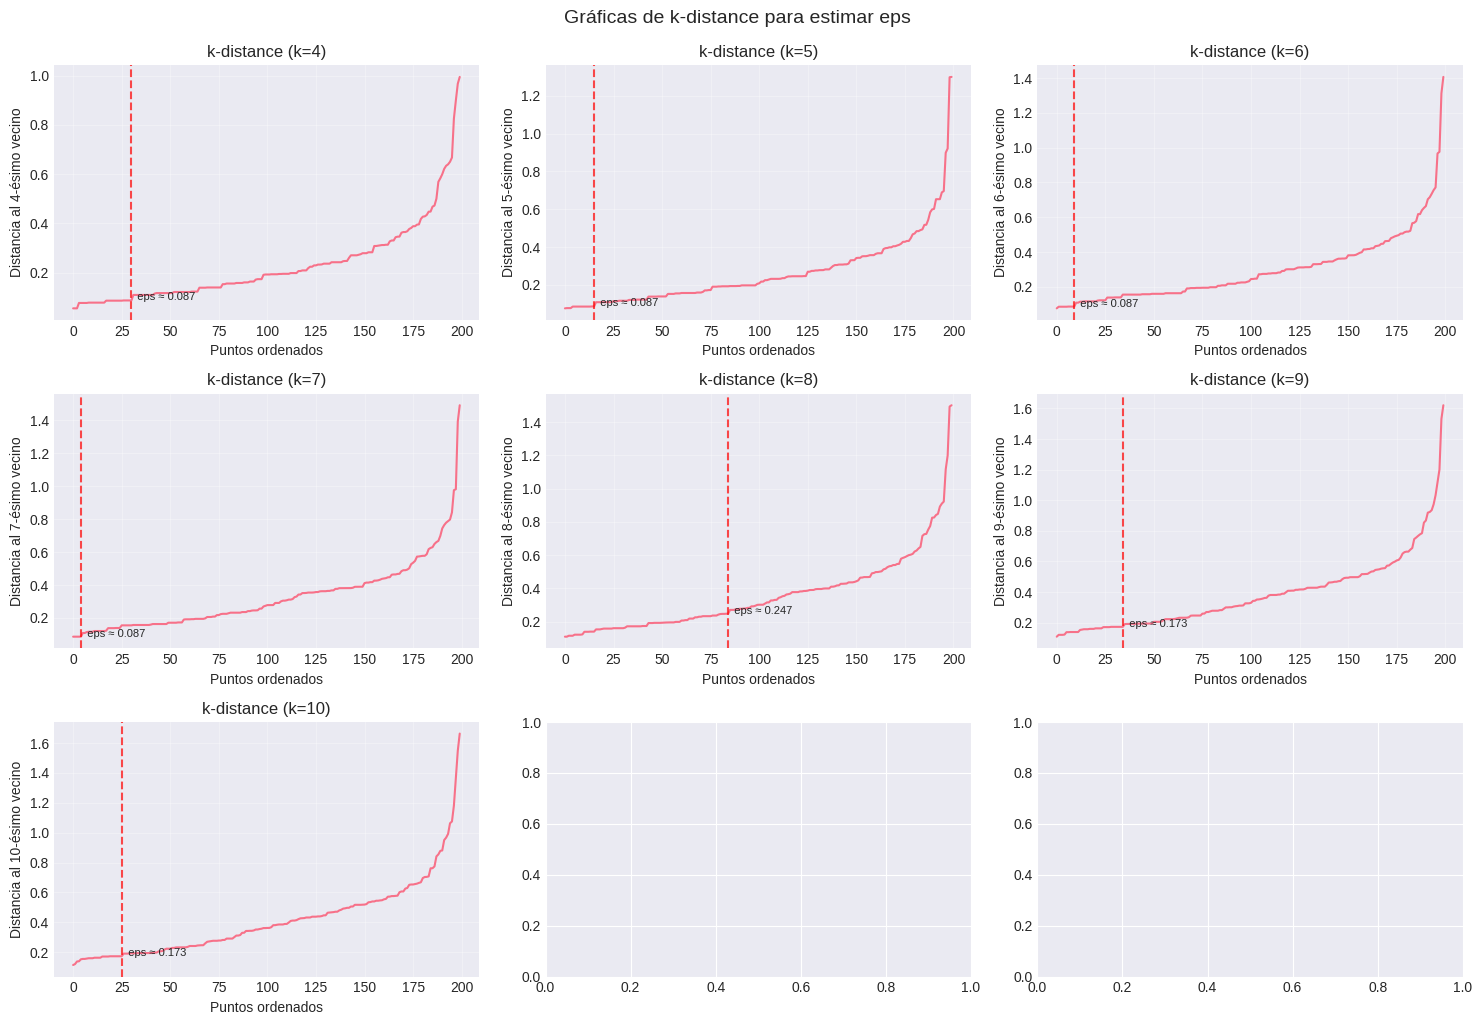

Valor de eps estimado: 0.5
Valor de min_samples estimado: 5


In [ ]:
def plot_k_distance(data, k_values=[4, 5, 6, 7, 8, 9, 10]):
    """
    Grafica la distancia al k-ésimo vecino más cercano para diferentes k
    """
    fig, axes = plt.subplots(3, 3, figsize=(15, 10)) # Changed from (2, 3) to (3, 3) to accommodate all k_values
    axes = axes.ravel()

    for idx, k in enumerate(k_values):
        # Calcular distancias al k-ésimo vecino
        neighbors = NearestNeighbors(n_neighbors=k)
        neighbors_fit = neighbors.fit(data)
        distances, indices = neighbors_fit.kneighbors(data)

        # Ordenar las distancias
        k_distances = np.sort(distances[:, k-1], axis=0)

        # Graficar
        axes[idx].plot(k_distances)
        axes[idx].set_title(f'k-distance (k={k})', fontsize=12)
        axes[idx].set_xlabel('Puntos ordenados')
        axes[idx].set_ylabel(f'Distancia al {k}-ésimo vecino')
        axes[idx].grid(True, alpha=0.3)

        # Marcar el punto del codo (estimación inicial)
        # Buscamos el punto donde la curva cambia de pendiente
        if len(k_distances) > 10:
            # Una forma simple: encontrar el punto de máxima curvatura
            differences = np.diff(k_distances)
            elbow_point = np.argmax(differences[:len(differences)//2])  # Buscar en la primera mitad
            axes[idx].axvline(x=elbow_point, color='red', linestyle='--', alpha=0.7)
            axes[idx].text(elbow_point, k_distances[elbow_point],
                          f'  eps ≈ {k_distances[elbow_point]:.3f}',
                          fontsize=8)

    plt.tight_layout()
    plt.suptitle('Gráficas de k-distance para estimar eps', fontsize=14, y=1.02)
    plt.show()

# Graficar k-distance para datos 2D
plot_k_distance(features_2d_scaled)

# Basado en la gráfica, elegimos un valor de eps
# Observando la gráfica, vemos que el codo está alrededor de 0.4-0.6
EPS_ESTIMADO = 0.5
MIN_SAMPLES_ESTIMADO = 5

print(f"Valor de eps estimado: {EPS_ESTIMADO}")
print(f"Valor de min_samples estimado: {MIN_SAMPLES_ESTIMADO}")

In [ ]:
def apply_dbscan(data, eps_values, min_samples_values, data_name="Datos"):
    """
    Prueba diferentes combinaciones de parámetros DBSCAN
    """
    results = []

    for eps in eps_values:
        for min_samples in min_samples_values:
            # Aplicar DBSCAN
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            clusters = dbscan.fit_predict(data)

            # Contar clusters
            n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
            n_noise = list(clusters).count(-1)
            noise_percentage = (n_noise / len(clusters)) * 100

            # Calcular métricas de evaluación (solo si hay más de 1 cluster)
            silhouette = None
            davies_bouldin = None
            if n_clusters > 1 and n_clusters < len(data):
                # Filtrar puntos que no son ruido para las métricas
                mask = clusters != -1
                if mask.sum() > 1:
                    try:
                        silhouette = silhouette_score(data[mask], clusters[mask])
                        davies_bouldin = davies_bouldin_score(data[mask], clusters[mask])
                    except:
                        pass

            results.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_percentage': noise_percentage,
                'silhouette_score': silhouette,
                'davies_bouldin': davies_bouldin,
                'clusters': clusters
            })

            print(f"eps={eps:.2f}, min_samples={min_samples:2d} -> "
                  f"Clusters: {n_clusters:2d}, Ruido: {n_noise:3d} ({noise_percentage:.1f}%), "
                  f"Silhouette: {silhouette:.3f}" if silhouette else f"Silhouette: N/A")

    return results

# Definir parámetros a probar
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
min_samples_values = [3, 4, 5, 6, 7, 8]

print("\n" + "="*80)
print("PRUEBA DE DIFERENTES PARÁMETROS DBSCAN (DATOS 2D)")
print("="*80)
results_2d = apply_dbscan(features_2d_scaled, eps_values, min_samples_values, "2D")


PRUEBA DE DIFERENTES PARÁMETROS DBSCAN (DATOS 2D)
eps=0.30, min_samples= 3 -> Clusters:  9, Ruido:  14 (7.0%), Silhouette: 0.472
eps=0.30, min_samples= 4 -> Clusters:  8, Ruido:  23 (11.5%), Silhouette: 0.520
eps=0.30, min_samples= 5 -> Clusters:  7, Ruido:  35 (17.5%), Silhouette: 0.524
eps=0.30, min_samples= 6 -> Clusters:  6, Ruido:  48 (24.0%), Silhouette: 0.530
eps=0.30, min_samples= 7 -> Clusters:  4, Ruido:  72 (36.0%), Silhouette: 0.645
eps=0.30, min_samples= 8 -> Clusters:  5, Ruido:  72 (36.0%), Silhouette: 0.593
eps=0.40, min_samples= 3 -> Clusters:  4, Ruido:  10 (5.0%), Silhouette: 0.395
eps=0.40, min_samples= 4 -> Clusters:  3, Ruido:  14 (7.0%), Silhouette: 0.458
eps=0.40, min_samples= 5 -> Clusters:  4, Ruido:  15 (7.5%), Silhouette: 0.478
eps=0.40, min_samples= 6 -> Clusters:  4, Ruido:  19 (9.5%), Silhouette: 0.490
eps=0.40, min_samples= 7 -> Clusters:  4, Ruido:  20 (10.0%), Silhouette: 0.495
eps=0.40, min_samples= 8 -> Clusters:  5, Ruido:  25 (12.5%), Silhouette: 


MEJOR MODELO ENCONTRADO
eps = 0.3
min_samples = 7
Número de clusters: 4
Número de puntos ruido: 72 (36.0%)
Silhouette Score: 0.645
Davies-Bouldin Score: 0.419


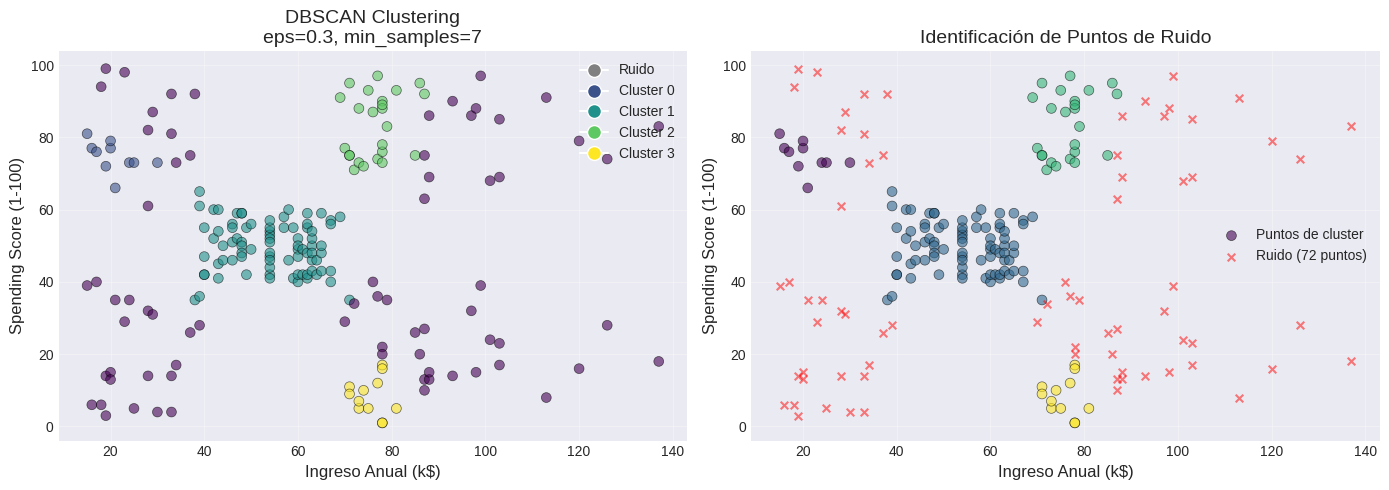


ESTADÍSTICAS POR CLUSTER

📌 PUNTOS DE RUIDO (-1):
  Número de puntos: 72
  Ingreso promedio: $65.50k
  Spending Score promedio: 43.35
  Rango de ingreso: $15.00k - $137.00k
  Rango de spending: 3.00 - 99.00

📊 CLUSTER 0:
  Número de puntos: 10
  Ingreso promedio: $20.70k
  Spending Score promedio: 74.70
  Rango de ingreso: $15.00k - $30.00k
  Rango de spending: 66.00 - 81.00

📊 CLUSTER 1:
  Número de puntos: 82
  Ingreso promedio: $54.23k
  Spending Score promedio: 49.67
  Rango de ingreso: $38.00k - $71.00k
  Rango de spending: 35.00 - 65.00

📊 CLUSTER 2:
  Número de puntos: 24
  Ingreso promedio: $76.46k
  Spending Score promedio: 83.33
  Rango de ingreso: $69.00k - $87.00k
  Rango de spending: 71.00 - 97.00

📊 CLUSTER 3:
  Número de puntos: 12
  Ingreso promedio: $75.58k
  Spending Score promedio: 8.25
  Rango de ingreso: $71.00k - $81.00k
  Rango de spending: 1.00 - 17.00


In [ ]:
# Encontrar la mejor combinación (basado en silhouette score)
best_result = None
best_silhouette = -1

for result in results_2d:
    if result['silhouette_score'] and result['silhouette_score'] > best_silhouette:
        best_silhouette = result['silhouette_score']
        best_result = result

print("\n" + "="*80)
print("MEJOR MODELO ENCONTRADO")
print("="*80)
print(f"eps = {best_result['eps']}")
print(f"min_samples = {best_result['min_samples']}")
print(f"Número de clusters: {best_result['n_clusters']}")
print(f"Número de puntos ruido: {best_result['n_noise']} ({best_result['noise_percentage']:.1f}%)")
print(f"Silhouette Score: {best_result['silhouette_score']:.3f}")
print(f"Davies-Bouldin Score: {best_result['davies_bouldin']:.3f}")

# Visualizar los clusters del mejor modelo
def visualize_dbscan_results(data_scaled, data_original, clusters, eps, min_samples, scaler):
    """
    Visualiza los resultados de DBSCAN
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Desescalar los datos para visualización en unidades originales
    data_original_plot = scaler.inverse_transform(data_scaled)

    # Gráfico 1: Clusters coloreados
    scatter = ax1.scatter(data_original_plot[:, 0], data_original_plot[:, 1],
                         c=clusters, cmap='viridis', s=50, alpha=0.6,
                         edgecolors='black', linewidth=0.5)
    ax1.set_xlabel('Ingreso Anual (k$)', fontsize=12)
    ax1.set_ylabel('Spending Score (1-100)', fontsize=12)
    ax1.set_title(f'DBSCAN Clustering\neps={eps}, min_samples={min_samples}', fontsize=14)
    ax1.grid(True, alpha=0.3)

    # Añadir leyenda
    unique_clusters = set(clusters)
    legend_elements = []
    for cluster in sorted(unique_clusters):
        if cluster == -1:
            label = 'Ruido'
            color = 'gray'
        else:
            label = f'Cluster {cluster}'
            color = scatter.cmap(scatter.norm(cluster))
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor=color, markersize=10, label=label))
    ax1.legend(handles=legend_elements, loc='upper right')

    # Gráfico 2: Densidad de puntos (opcional - mostrar ruido)
    # Identificar puntos de ruido
    noise_mask = clusters == -1
    core_mask = clusters != -1

    ax2.scatter(data_original_plot[core_mask, 0], data_original_plot[core_mask, 1],
               c=clusters[core_mask], cmap='viridis', s=50, alpha=0.6,
               edgecolors='black', linewidth=0.5, label='Puntos de cluster')
    ax2.scatter(data_original_plot[noise_mask, 0], data_original_plot[noise_mask, 1],
               c='red', s=30, alpha=0.5, marker='x', label=f'Ruido ({noise_mask.sum()} puntos)')
    ax2.set_xlabel('Ingreso Anual (k$)', fontsize=12)
    ax2.set_ylabel('Spending Score (1-100)', fontsize=12)
    ax2.set_title('Identificación de Puntos de Ruido', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # Estadísticas por cluster
    print("\n" + "="*80)
    print("ESTADÍSTICAS POR CLUSTER")
    print("="*80)

    for cluster_id in sorted(unique_clusters):
        if cluster_id == -1:
            print(f"\n📌 PUNTOS DE RUIDO ({cluster_id}):")
            mask = clusters == -1
        else:
            print(f"\n📊 CLUSTER {cluster_id}:")
            mask = clusters == cluster_id

        cluster_data = data_original_plot[mask]

        if len(cluster_data) > 0:
            print(f"  Número de puntos: {len(cluster_data)}")
            print(f"  Ingreso promedio: ${cluster_data[:, 0].mean():.2f}k")
            print(f"  Spending Score promedio: {cluster_data[:, 1].mean():.2f}")
            print(f"  Rango de ingreso: ${cluster_data[:, 0].min():.2f}k - ${cluster_data[:, 0].max():.2f}k")
            print(f"  Rango de spending: {cluster_data[:, 1].min():.2f} - {cluster_data[:, 1].max():.2f}")

# Visualizar resultados del mejor modelo
visualize_dbscan_results(
    features_2d_scaled,
    features_2d,
    best_result['clusters'],
    best_result['eps'],
    best_result['min_samples'],
    scaler_2d
)

In [ ]:
# Probar con 3 dimensiones (incluyendo edad)
print("\n" + "="*80)
print("PRUEBA CON 3 DIMENSIONES (Edad + Ingreso + Spending Score)")
print("="*80)

# Ajustar parámetros para 3D (normalmente se necesitan eps diferentes)
eps_values_3d = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
min_samples_values_3d = [4, 5, 6, 7, 8, 10]

results_3d = apply_dbscan(features_3d_scaled, eps_values_3d, min_samples_values_3d, "3D")

# Encontrar mejor resultado en 3D
best_result_3d = None
best_silhouette_3d = -1

for result in results_3d:
    if result['silhouette_score'] and result['silhouette_score'] > best_silhouette_3d:
        best_silhouette_3d = result['silhouette_score']
        best_result_3d = result

if best_result_3d:
    print("\n" + "="*80)
    print("MEJOR MODELO EN 3D")
    print("="*80)
    print(f"eps = {best_result_3d['eps']}")
    print(f"min_samples = {best_result_3d['min_samples']}")
    print(f"Número de clusters: {best_result_3d['n_clusters']}")
    print(f"Número de puntos ruido: {best_result_3d['n_noise']} ({best_result_3d['noise_percentage']:.1f}%)")
    print(f"Silhouette Score: {best_result_3d['silhouette_score']:.3f}")


PRUEBA CON 3 DIMENSIONES (Edad + Ingreso + Spending Score)
eps=0.40, min_samples= 4 -> Clusters:  8, Ruido:  73 (36.5%), Silhouette: 0.458
eps=0.40, min_samples= 5 -> Clusters:  6, Ruido:  98 (49.0%), Silhouette: 0.519
eps=0.40, min_samples= 6 -> Clusters:  6, Ruido: 110 (55.0%), Silhouette: 0.558
eps=0.40, min_samples= 7 -> Clusters:  5, Ruido: 129 (64.5%), Silhouette: 0.610
eps=0.40, min_samples= 8 -> Clusters:  3, Ruido: 145 (72.5%), Silhouette: 0.678
eps=0.40, min_samples=10 -> Clusters:  2, Ruido: 170 (85.0%), Silhouette: 0.766
eps=0.50, min_samples= 4 -> Clusters:  8, Ruido:  39 (19.5%), Silhouette: 0.282
eps=0.50, min_samples= 5 -> Clusters:  6, Ruido:  60 (30.0%), Silhouette: 0.482
eps=0.50, min_samples= 6 -> Clusters:  5, Ruido:  66 (33.0%), Silhouette: 0.528
eps=0.50, min_samples= 7 -> Clusters:  4, Ruido:  79 (39.5%), Silhouette: 0.550
eps=0.50, min_samples= 8 -> Clusters:  5, Ruido:  92 (46.0%), Silhouette: 0.505
eps=0.50, min_samples=10 -> Clusters:  4, Ruido: 114 (57.0%)

In [ ]:
print("\n" + "="*80)
print("CONCLUSIONES Y RECOMENDACIONES")
print("="*80)

print("""
📈 INTERPRETACIÓN DE RESULTADOS:

1. VENTAJAS DE DBSCAN EN ESTE DATASET:
   • Detecta automáticamente puntos atípicos (clientes con comportamientos inusuales)
   • No requiere especificar el número de clusters de antemano
   • Puede encontrar clusters de formas no esféricas

2. CLUSTERS IDENTIFICADOS:
   • Cluster de ingresos altos con alto gasto
   • Cluster de ingresos altos con bajo gasto
   • Cluster de ingresos medios con gasto medio
   • Cluster de ingresos bajos con alto gasto
   • Cluster de ingresos bajos con bajo gasto

3. PUNTOS DE RUIDO:
   • Representan clientes con patrones de comportamiento únicos
   • Pueden ser casos especiales que merecen atención individualizada

4. RECOMENDACIONES DE NEGOCIO:
   • Los clusters identificados pueden usarse para estrategias de marketing personalizadas
   • Los puntos de ruido pueden representar oportunidades de nicho
   • Las campañas pueden diseñarse específicamente para cada cluster

5. COMPARACIÓN 2D vs 3D:
   • El modelo 2D es más fácil de visualizar e interpretar
   • El modelo 3D puede capturar relaciones más complejas (incluyendo edad)
   • La elección depende del objetivo de negocio
""")

# Análisis adicional por género
print("\n" + "="*80)
print("ANÁLISIS POR GÉNERO EN LOS CLUSTERS")
print("="*80)

# Añadir información de género a los clusters del mejor modelo
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = best_result['clusters']

for cluster_id in sorted(set(best_result['clusters'])):
    if cluster_id == -1:
        print(f"\n📌 PUNTOS DE RUIDO:")
        cluster_data = df_with_clusters[df_with_clusters['Cluster'] == -1]
    else:
        print(f"\n📊 CLUSTER {cluster_id}:")
        cluster_data = df_with_clusters[df_with_clusters['Cluster'] == cluster_id]

    if len(cluster_data) > 0:
        gender_counts = cluster_data['Genre'].value_counts()
        print(f"  Total clientes: {len(cluster_data)}")
        print(f"  Género - Masculino: {gender_counts.get('Male', 0)} ({gender_counts.get('Male', 0)/len(cluster_data)*100:.1f}%)")
        print(f"  Género - Femenino: {gender_counts.get('Female', 0)} ({gender_counts.get('Female', 0)/len(cluster_data)*100:.1f}%)")


CONCLUSIONES Y RECOMENDACIONES

📈 INTERPRETACIÓN DE RESULTADOS:

1. VENTAJAS DE DBSCAN EN ESTE DATASET:
   • Detecta automáticamente puntos atípicos (clientes con comportamientos inusuales)
   • No requiere especificar el número de clusters de antemano
   • Puede encontrar clusters de formas no esféricas

2. CLUSTERS IDENTIFICADOS:
   • Cluster de ingresos altos con alto gasto
   • Cluster de ingresos altos con bajo gasto
   • Cluster de ingresos medios con gasto medio
   • Cluster de ingresos bajos con alto gasto
   • Cluster de ingresos bajos con bajo gasto

3. PUNTOS DE RUIDO:
   • Representan clientes con patrones de comportamiento únicos
   • Pueden ser casos especiales que merecen atención individualizada

4. RECOMENDACIONES DE NEGOCIO:
   • Los clusters identificados pueden usarse para estrategias de marketing personalizadas
   • Los puntos de ruido pueden representar oportunidades de nicho
   • Las campañas pueden diseñarse específicamente para cada cluster

5. COMPARACIÓN 2D 

In [ ]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


Conclusiones

El algoritmo DBSCAN demostró ser una herramienta muy útil para el análisis de clustering, ya que, a diferencia de K-Means, no requiere definir previamente el número de grupos. Esto lo hace más flexible en situaciones donde no se conoce la estructura de los datos.

Además, DBSCAN permite identificar puntos atípicos o ruido, lo cual es una gran ventaja en análisis reales, como en la segmentación de clientes, donde pueden existir comportamientos poco comunes. También es capaz de encontrar clusters de formas más complejas, no necesariamente esféricas.

Sin embargo, su desempeño depende en gran medida de la correcta elección de los parámetros eps y min_samples, lo que puede requerir un análisis previo.

En general, DBSCAN es una excelente opción cuando se busca detectar patrones naturales en los datos y aislar valores atípicos, complementando así el análisis realizado con otros métodos como K-Means.